In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV, cross_val_score

print('All libraries imported successfully')
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip "UCI HAR Dataset.zip"

All libraries imported successfully
--2026-04-18 05:11:08--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [              <=>   ]  58.17M  12.9MB/s    in 7.9s    

2026-04-18 05:11:19 (7.39 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflat

### Cell 1 — Load dataset

In [2]:
def load_data():
    print('Loading UCI HAR Dataset...')
    data_folder = '/content/UCI HAR Dataset/'
    features    = pd.read_csv(data_folder + 'features.txt', sep='\\s+', header=None, names=['id','name'])
    columnNames = features['name'].values
    labelsMap   = pd.read_csv(data_folder + 'activity_labels.txt', sep='\\s+', header=None, names=['id','activity_name'])

    def read_set(set_name):
        X       = pd.read_csv(f'{data_folder}{set_name}/X_{set_name}.txt', sep='\\s+', header=None)
        X.columns = columnNames
        y       = pd.read_csv(f'{data_folder}{set_name}/y_{set_name}.txt', sep='\\s+', header=None, names=['Activity_ID'])
        y['Activity_Name'] = y['Activity_ID'].map(labelsMap.set_index('id')['activity_name'])
        subject = pd.read_csv(f'{data_folder}{set_name}/subject_{set_name}.txt', sep='\\s+', header=None, names=['Subject_ID'])
        return pd.concat([subject, y, X], axis=1)

    train_df = read_set('train')
    test_df  = read_set('test')
    print(f'Train shape : {train_df.shape}')
    print(f'Test  shape : {test_df.shape}')
    return train_df, test_df

train_data, test_data = load_data()
train_data.head(3)

Loading UCI HAR Dataset...
Train shape : (7352, 564)
Test  shape : (2947, 564)


,Subject_ID,Activity_ID,Activity_Name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118


### Cell 2 — Load raw inertial signals

In [3]:
def load_inertial_signals(set_name):
    print(f'Loading raw signals for {set_name}...')
    data_folder = f'/content/UCI HAR Dataset/{set_name}/Inertial Signals/'
    filenames = [
        'body_acc_x_','body_acc_y_','body_acc_z_',
        'body_gyro_x_','body_gyro_y_','body_gyro_z_',
        'total_acc_x_','total_acc_y_','total_acc_z_'
    ]
    signals = []
    for name in filenames:
        data = pd.read_csv(f'{data_folder}{name}{set_name}.txt', sep='\\s+', header=None)
        signals.append(data.values)
    return np.transpose(np.array(signals), (1, 2, 0))

X_train_raw = load_inertial_signals('train')
X_test_raw  = load_inertial_signals('test')
print(f'X_train_raw shape : {X_train_raw.shape}  -> (samples, timesteps, signals)')
print(f'X_test_raw  shape : {X_test_raw.shape}')

Loading raw signals for train...
Loading raw signals for test...
X_train_raw shape : (7352, 128, 9)  -> (samples, timesteps, signals)
X_test_raw  shape : (2947, 128, 9)


### Cell 3 — Data quality checks

In [4]:
print('=== Data Quality Report ===')
print(f'NaN in train     : {train_data.isnull().sum().sum()}')
print(f'NaN in test      : {test_data.isnull().sum().sum()}')
print(f'Duplicate rows   : {train_data.duplicated().sum()}')
print()
print('=== Train / Test Split ===')
total = train_data.shape[0] + test_data.shape[0]
print(f'Train : {train_data.shape[0]} samples ({train_data.shape[0]/total:.0%})')
print(f'Test  : {test_data.shape[0]} samples ({test_data.shape[0]/total:.0%})')
print()
print('=== Class Distribution (train) ===')
print(train_data['Activity_Name'].value_counts())

=== Data Quality Report ===
NaN in train     : 0
NaN in test      : 0
Duplicate rows   : 0

=== Train / Test Split ===
Train : 7352 samples (71%)
Test  : 2947 samples (29%)

=== Class Distribution (train) ===
Activity_Name
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


### Cell 4 — Activity class balance

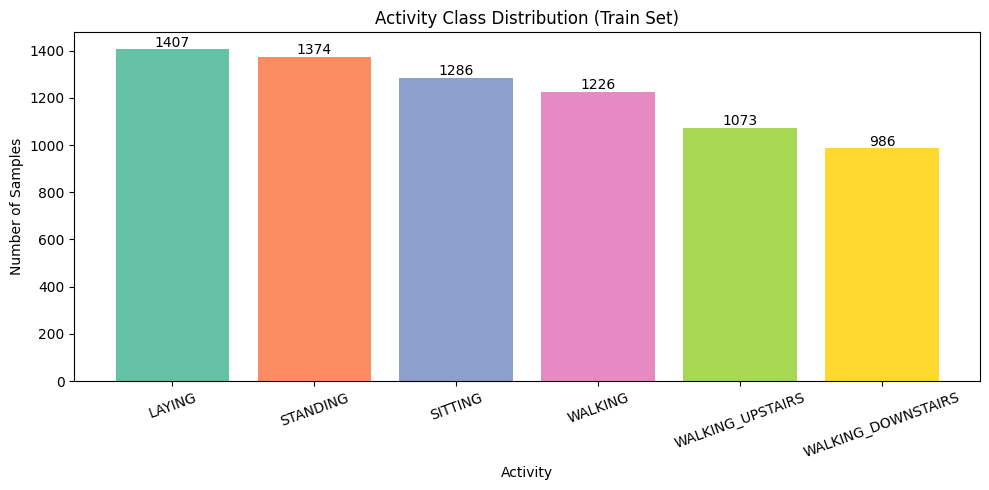

Insight: Classes are roughly balanced — no major imbalance issue.


In [5]:
plt.figure(figsize=(10, 5))
counts = train_data['Activity_Name'].value_counts()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
plt.title('Activity Class Distribution (Train Set)')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Insight: Classes are roughly balanced — no major imbalance issue.')

### Cell 5 — Sensor signal plots per activity

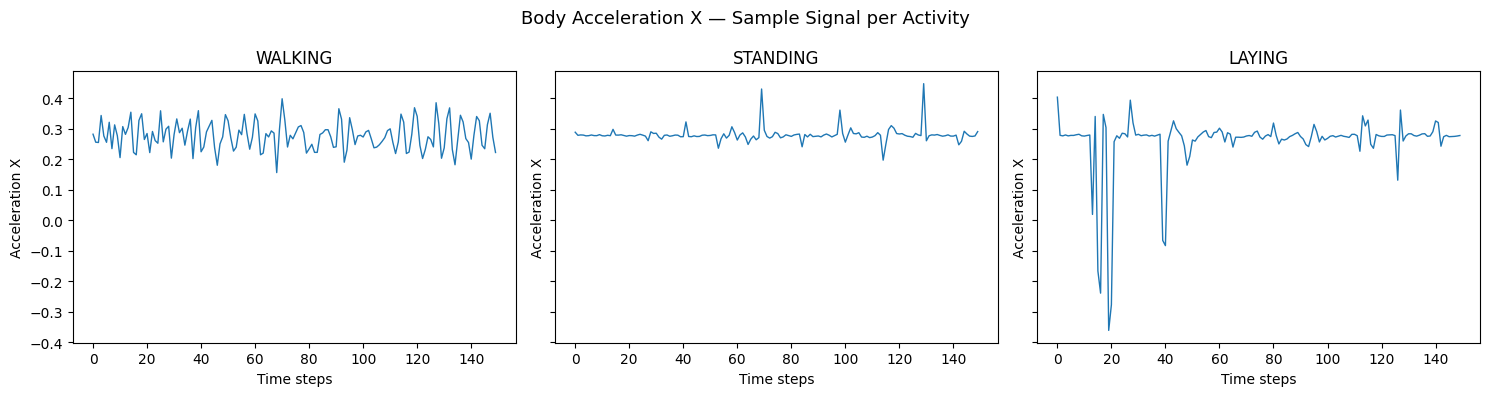

Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.


In [6]:
activities  = ['WALKING', 'STANDING', 'LAYING']
signal_col  = 'tBodyAcc-mean()-X'
fig, axes   = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, activity in zip(axes, activities):
    subset = train_data[train_data['Activity_Name'] == activity][signal_col].values[:150]
    ax.plot(subset, linewidth=1)
    ax.set_title(f'{activity}')
    ax.set_xlabel('Time steps')
    ax.set_ylabel('Acceleration X')

plt.suptitle('Body Acceleration X — Sample Signal per Activity', fontsize=13)
plt.tight_layout()
plt.show()
print('Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.')

### Cell 6 — Correlation matrix (first 20 features)

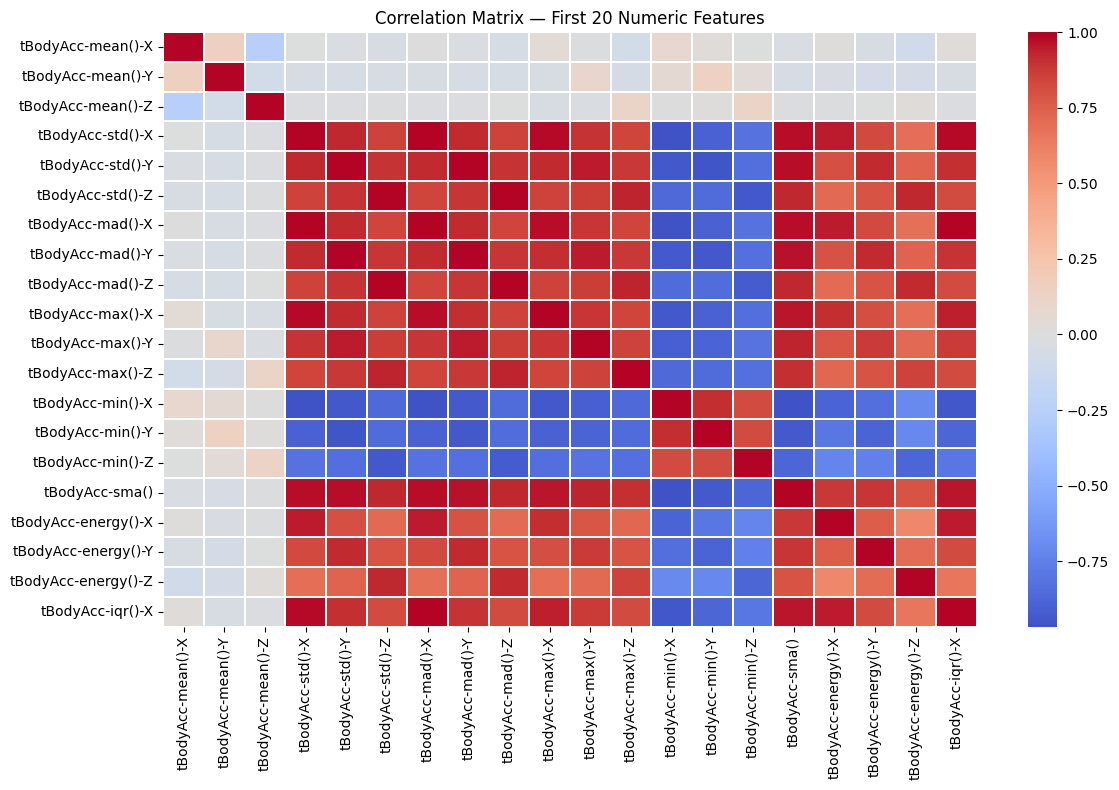

Insight: High correlation between some body acceleration features — expected for XYZ axes.


In [7]:
numeric_data = train_data.select_dtypes(include=['number'])
corr = numeric_data.iloc[:, 2:22].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlation Matrix — First 20 Numeric Features')
plt.tight_layout()
plt.show()
print('Insight: High correlation between some body acceleration features — expected for XYZ axes.')

### Cell 7 — Distribution plots

/tmp/ipykernel_6703/1652785480.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')


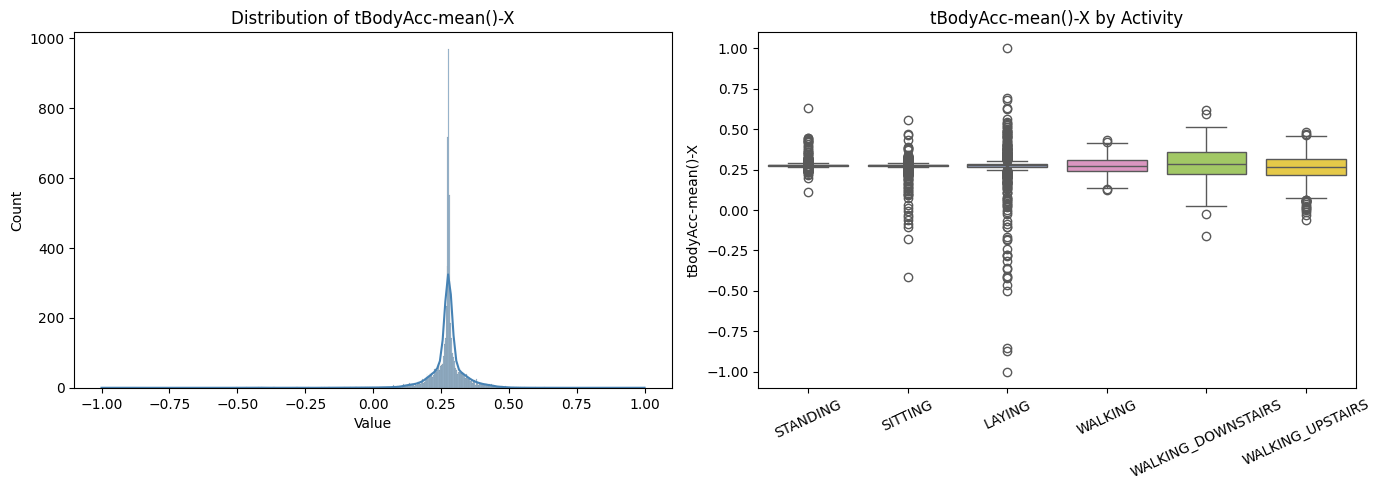

Insight: Body acceleration X clearly separates walking activities from static ones.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_data.iloc[:, 2], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of {numeric_data.columns[2]}')
axes[0].set_xlabel('Value')


feature = 'tBodyAcc-mean()-X'
sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')
axes[1].set_title(f'{feature} by Activity')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('Insight: Body acceleration X clearly separates walking activities from static ones.')

### Cell 8 — Signal names

In [9]:
SIGNAL_NAMES = [
    'body_acc_x','body_acc_y','body_acc_z',
    'body_gyro_x','body_gyro_y','body_gyro_z',
    'total_acc_x','total_acc_y','total_acc_z'
]
print(f'Number of signals : {len(SIGNAL_NAMES)}')
print(f'Signal names      : {SIGNAL_NAMES}')

Number of signals : 9
Signal names      : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


### Cell 9 — Time-domain features (mean, std, min, max, median, skew, kurtosis)

In [10]:
def extract_time_domain_features(raw_data):
    print('Extracting time-domain features...')
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal = sample[:, i]
            row[f'{sig_name}_mean']     = np.mean(signal)
            row[f'{sig_name}_std']      = np.std(signal)
            row[f'{sig_name}_min']      = np.min(signal)
            row[f'{sig_name}_max']      = np.max(signal)
            row[f'{sig_name}_median']   = np.median(signal)
            row[f'{sig_name}_skew']     = skew(signal)
            row[f'{sig_name}_kurtosis'] = kurtosis(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 7 stats = 63 features)')
    return df

X_train_time = extract_time_domain_features(X_train_raw)
X_test_time  = extract_time_domain_features(X_test_raw)
X_train_time.head(3)

Extracting time-domain features...
  Output shape : (7352, 63)  (9 signals x 7 stats = 63 features)
Extracting time-domain features...
  Output shape : (2947, 63)  (9 signals x 7 stats = 63 features)


,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,body_acc_y_mean,body_acc_y_std,body_acc_y_min,...,total_acc_y_median,total_acc_y_skew,total_acc_y_kurtosis,total_acc_z_mean,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_skew,total_acc_z_kurtosis
0,0.002269,0.002941,-0.004294,0.010810,0.002025,0.481111,-0.395797,-0.001655,0.004601,-0.012610,...,-0.124302,-0.034474,-0.408672,0.099732,0.003970,0.088742,0.109485,0.099841,0.071125,0.493800
1,0.000174,0.001981,-0.006706,0.005251,0.000110,-0.480776,1.472747,0.000382,0.005930,-0.012610,...,-0.123188,0.488232,0.163722,0.096939,0.004918,0.081100,0.105788,0.097748,-1.084209,1.257869
2,0.000428,0.002908,-0.010483,0.008167,0.000627,-0.565241,1.802622,-0.001222,0.007310,-0.015333,...,-0.125918,0.366785,-0.640148,0.092897,0.006145,0.081100,0.105788,0.093636,-0.144007,-0.716645


### Cell 10 — Frequency-domain features (FFT)

In [11]:
def spectral_entropy(signal):
    fft_vals = np.abs(fft(signal))[:len(signal)//2]
    power    = fft_vals ** 2
    total    = np.sum(power)
    if total == 0:
        return 0.0
    prob = power / total
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def extract_fft_features(raw_data, sampling_rate=50):
    print('Extracting FFT features...')
    n_timesteps = raw_data.shape[1]
    freqs       = np.fft.fftfreq(n_timesteps, d=1.0/sampling_rate)[:n_timesteps//2]
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal   = sample[:, i]
            fft_vals = np.abs(fft(signal))[:n_timesteps//2]
            row[f'{sig_name}_fft_dominant_freq']    = freqs[np.argmax(fft_vals)]
            row[f'{sig_name}_fft_energy']           = np.sum(fft_vals ** 2)
            row[f'{sig_name}_fft_spectral_entropy'] = spectral_entropy(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 3 stats = 27 features)')
    return df

X_train_fft = extract_fft_features(X_train_raw)
X_test_fft  = extract_fft_features(X_test_raw)
X_train_fft.head(3)

Extracting FFT features...
  Output shape : (7352, 27)  (9 signals x 3 stats = 27 features)
Extracting FFT features...
  Output shape : (2947, 27)  (9 signals x 3 stats = 27 features)


,body_acc_x_fft_dominant_freq,body_acc_x_fft_energy,body_acc_x_fft_spectral_entropy,body_acc_y_fft_dominant_freq,body_acc_y_fft_energy,body_acc_y_fft_spectral_entropy,body_acc_z_fft_dominant_freq,body_acc_z_fft_energy,body_acc_z_fft_spectral_entropy,body_gyro_x_fft_dominant_freq,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,0.00000,0.155185,2.610402,0.390625,0.218277,3.594107,0.390625,3.886445,2.556959,0.000000,...,1.344905,0.0,17022.704179,0.000040,0.0,253.073153,0.006050,0.0,163.091410,0.012904
1,7.03125,0.032640,4.761714,0.390625,0.290422,3.365968,0.000000,1.252940,2.680912,0.000000,...,2.333451,0.0,17027.498428,0.000045,0.0,247.813017,0.012676,0.0,154.162921,0.019843
2,0.78125,0.072294,4.779093,0.390625,0.462221,2.989540,0.390625,0.424719,3.435523,0.390625,...,3.248716,0.0,17043.526416,0.000098,0.0,256.328623,0.019163,0.0,141.700207,0.030712


### Cell 11 — Combine all features (63 + 27 = 90)

In [12]:
X_train_feats = pd.concat([X_train_time, X_train_fft], axis=1)
X_test_feats  = pd.concat([X_test_time,  X_test_fft],  axis=1)
print(f'X_train_feats : {X_train_feats.shape}')
print(f'X_test_feats  : {X_test_feats.shape}')
print(f'Total features: {X_train_feats.shape[1]}  (63 time-domain + 27 FFT)')

X_train_feats : (7352, 90)
X_test_feats  : (2947, 90)
Total features: 90  (63 time-domain + 27 FFT)


### Cell 12 — StandardScaler (fit on train only)

In [13]:
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_feats), columns=X_train_feats.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_feats),      columns=X_test_feats.columns)
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Test  scaled shape : {X_test_scaled.shape}')
print('\nVerify — train mean should be ~0 and std ~1:')
print(X_train_scaled.describe().loc[['mean','std']].round(3).iloc[:, :5])

Train scaled shape : (7352, 90)
Test  scaled shape : (2947, 90)

Verify — train mean should be ~0 and std ~1:
      body_acc_x_mean  body_acc_x_std  body_acc_x_min  body_acc_x_max  \
mean              0.0             0.0             0.0            -0.0   
std               1.0             1.0             1.0             1.0   

      body_acc_x_median  
mean               -0.0  
std                 1.0  


### Cell 13 — Attach labels and export CSVs

In [14]:
train_labels = train_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)
test_labels  = test_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)

train_final = pd.concat([train_labels, X_train_scaled.reset_index(drop=True)], axis=1)
test_final  = pd.concat([test_labels,  X_test_scaled.reset_index(drop=True)],  axis=1)

train_final.to_csv('train_features.csv', index=False)
test_final.to_csv('test_features.csv',   index=False)

print('Saved: train_features.csv')
print('Saved: test_features.csv')
print(f'\ntrain_final shape : {train_final.shape}')
print(f'test_final  shape : {test_final.shape}')
train_final.head(3)

Saved: train_features.csv
Saved: test_features.csv

train_final shape : (7352, 93)
test_final  shape : (2947, 93)


,Subject_ID,Activity_ID,Activity_Name,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,1,5,STANDING,0.200642,-0.868814,0.906009,-0.856036,0.587177,0.383365,-0.331063,...,-1.676605,-0.04378,0.610645,-0.550501,-0.129234,-0.587056,-0.818857,-0.274773,-0.566725,-0.812263
1,1,5,STANDING,0.055948,-0.875426,0.895998,-0.871359,0.544547,-1.181161,0.631206,...,-0.703240,-0.04378,0.611394,-0.550488,-0.129234,-0.588493,-0.813157,-0.274773,-0.569294,-0.807098
2,1,5,STANDING,0.073515,-0.869039,0.880323,-0.863323,0.556060,-1.318546,0.801087,...,0.197969,-0.04378,0.613897,-0.550355,-0.129234,-0.586166,-0.807577,-0.274773,-0.572879,-0.799007


### Cell 14 — PCA Visualization (Dimensionality Reduction)

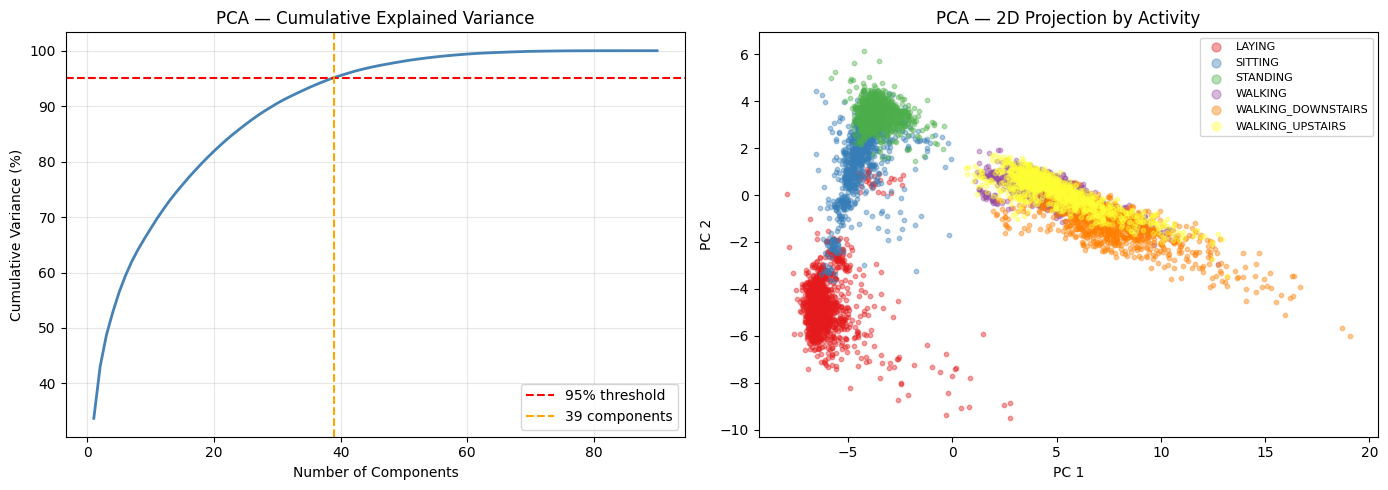

Insight: 39 components explain 95% of variance (out of 90 original features)


In [15]:
feature_cols = X_train_scaled.columns.tolist()
X_train      = train_final[feature_cols]
y_train      = train_final['Activity_ID']
X_test       = test_final[feature_cols]
y_test       = test_final['Activity_ID']

pca_full     = PCA()
pca_full.fit(X_train)
cumvar        = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95          = np.argmax(cumvar >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} components')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


pca2d     = PCA(n_components=2)
X_pca2d   = pca2d.fit_transform(X_train)
activity_names = train_final['Activity_Name'].values
unique_acts    = np.unique(activity_names)
colors         = sns.color_palette('Set1', len(unique_acts))

for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=act, alpha=0.4, s=10, color=col)

axes[1].set_title('PCA — 2D Projection by Activity')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()
print(f'Insight: {n_95} components explain 95% of variance (out of {X_train.shape[1]} original features)')

### Cell 15 — LDA Visualization

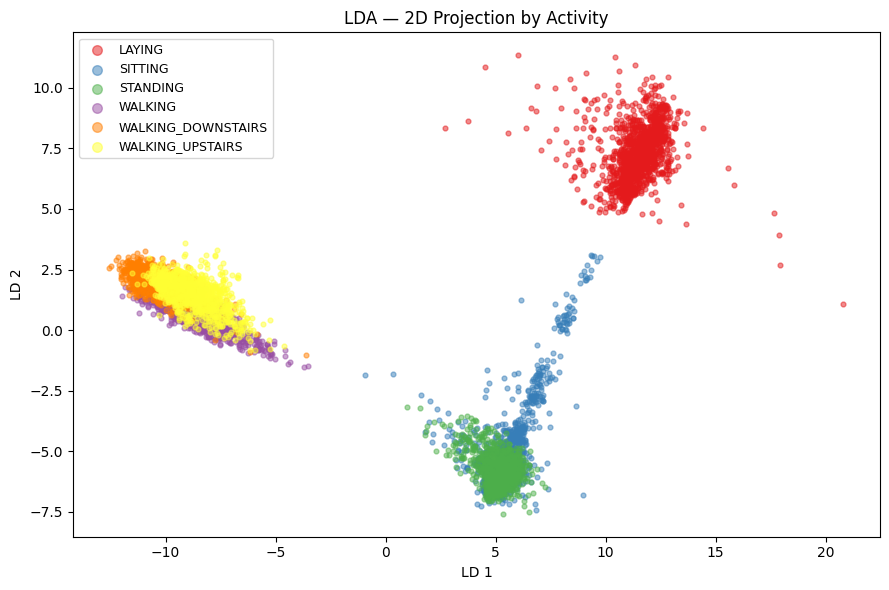

Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.


In [16]:
lda     = LDA(n_components=2)
X_lda2d = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(9, 6))
for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    plt.scatter(X_lda2d[mask, 0], X_lda2d[mask, 1], label=act, alpha=0.5, s=12, color=col)

plt.title('LDA — 2D Projection by Activity')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.')

### Cell 16 — Encode labels

In [17]:
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

Classes: [1 2 3 4 5 6]
Encoded: [0 1 2 3 4 5]


### Cell 17 — Train all models (KNN, Naive Bayes, Random Forest, Gradient Boosting)

In [18]:
models = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'       : GaussianNB(),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test_enc, y_pred)
    f1     = f1_score(y_test_enc, y_pred, average='weighted')
    roc    = roc_auc_score(y_test_enc, model.predict_proba(X_test), multi_class='ovr', average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1 Score': round(f1,4), 'ROC AUC': round(roc,4)})
    trained_models[name] = (model, y_pred)
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Results Summary ===')
print(results_df.to_string(index=False))

Training KNN...
  Accuracy: 0.8514 | F1: 0.8517 | ROC AUC: 0.9717
Training Naive Bayes...
  Accuracy: 0.8405 | F1: 0.8344 | ROC AUC: 0.9820
Training Random Forest...
  Accuracy: 0.9019 | F1: 0.9017 | ROC AUC: 0.9914
Training Gradient Boosting...
  Accuracy: 0.9104 | F1: 0.9103 | ROC AUC: 0.9924

=== Results Summary ===
            Model  Accuracy  F1 Score  ROC AUC
              KNN    0.8514    0.8517   0.9717
      Naive Bayes    0.8405    0.8344   0.9820
    Random Forest    0.9019    0.9017   0.9914
Gradient Boosting    0.9104    0.9103   0.9924


### Cell 18 — Confusion matrices for all models

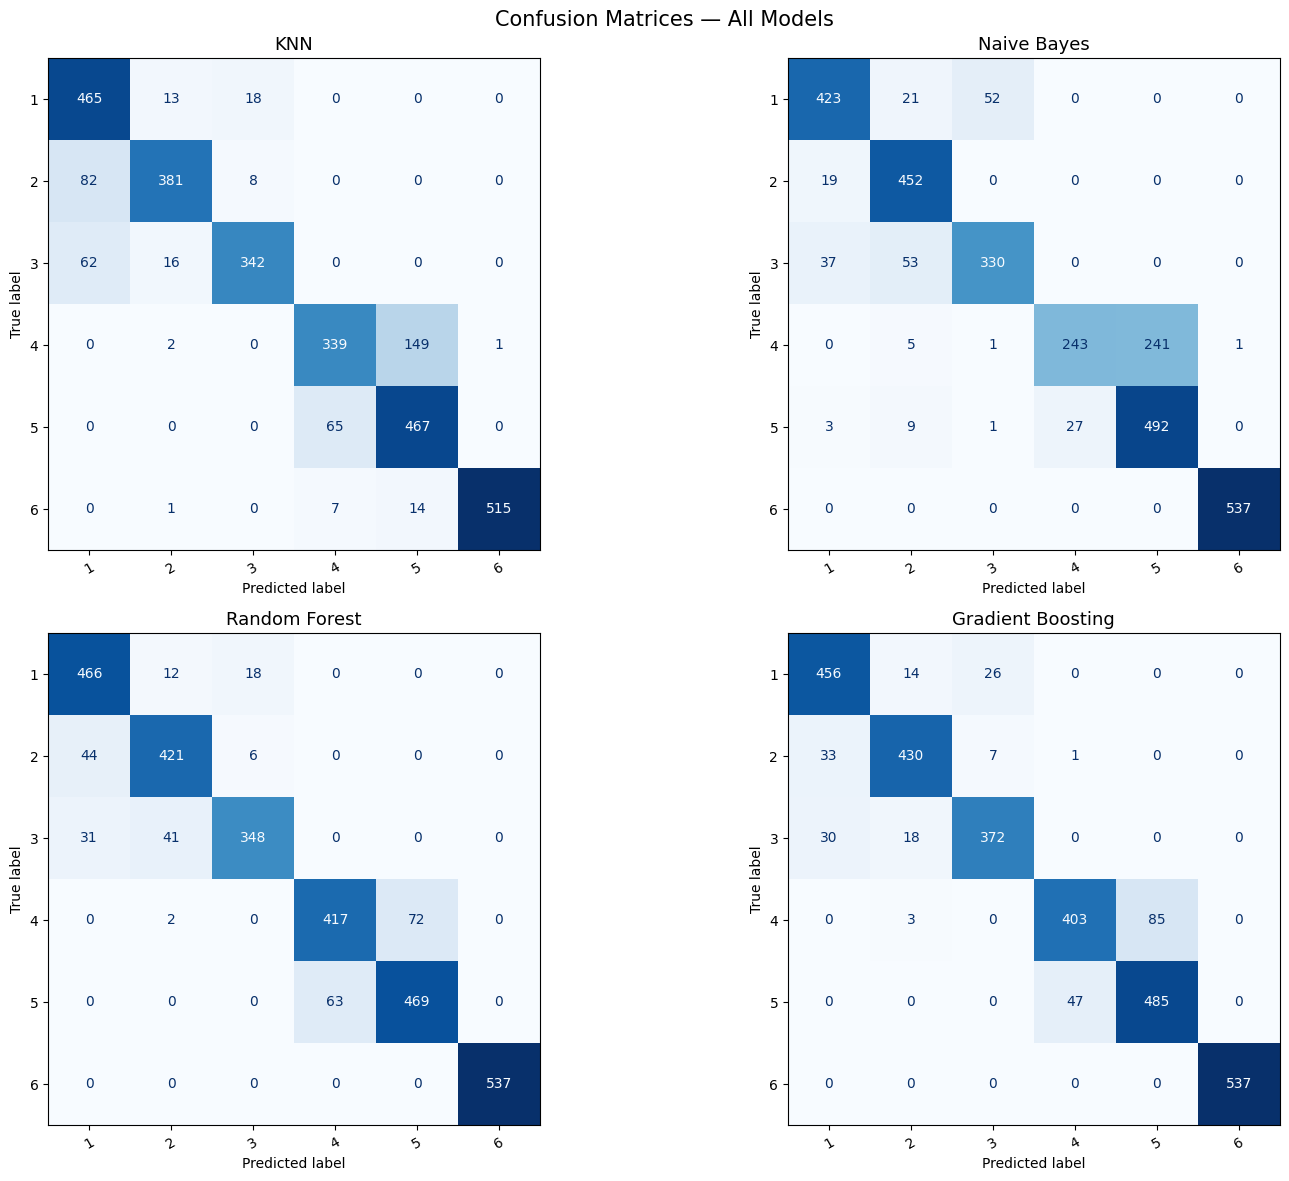

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

### Cell 19 — Hyperparameter tuning (KNN & Random Forest)

In [20]:
print('Tuning KNN...')
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid   = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train_enc)
print(f'  Best k : {knn_grid.best_params_}  |  CV Accuracy : {knn_grid.best_score_:.4f}')

print('Tuning Random Forest...')
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
rf_grid   = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train_enc)
print(f'  Best params : {rf_grid.best_params_}  |  CV Accuracy : {rf_grid.best_score_:.4f}')

Tuning KNN...
  Best k : {'n_neighbors': 9}  |  CV Accuracy : 0.8679
Tuning Random Forest...
  Best params : {'max_depth': 10, 'n_estimators': 50}  |  CV Accuracy : 0.8852


### Cell 20 — Final results bar chart

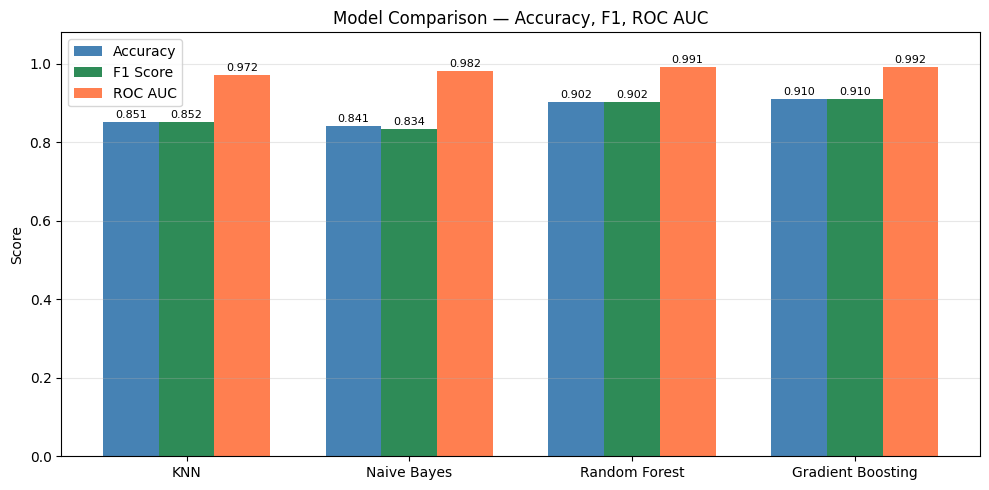

Best model by accuracy: Gradient Boosting


In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(results_df))
width   = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x,         results_df['F1 Score'], width, label='F1 Score',  color='seagreen')
bars3 = ax.bar(x + width, results_df['ROC AUC'],  width, label='ROC AUC',   color='coral')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison — Accuracy, F1, ROC AUC')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
best = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f'Best model by accuracy: {best}')

# PHASE 2


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



In [23]:
le_cnn = LabelEncoder()

y_train_cnn = le_cnn.fit_transform(train_data['Activity_Name'].values)
y_test_cnn  = le_cnn.transform(test_data['Activity_Name'].values)

NUM_CLASSES = len(le_cnn.classes_)


y_train_oh = to_categorical(y_train_cnn, NUM_CLASSES)
y_test_oh  = to_categorical(y_test_cnn,  NUM_CLASSES)

print(f'X_train_raw : {X_train_raw.shape}  →  (samples, timesteps=128, channels=9)')
print(f'y_train_oh  : {y_train_oh.shape}')
print(f'Classes     : {list(le_cnn.classes_)}')


X_train_raw : (7352, 128, 9)  →  (samples, timesteps=128, channels=9)
y_train_oh  : (7352, 6)
Classes     : ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [24]:
def build_1d_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape, name='raw_signals')


    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)


    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)


    x = layers.Conv1D(256, kernel_size=3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)


    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(64,  activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs, outputs, name='HAR_1D_CNN')

cnn_model = build_1d_cnn(input_shape=(128, 9), num_classes=NUM_CLASSES)
cnn_model.summary()


Model: "HAR_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signals (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,542 (662.27 KB)

 Trainable params: 168,646 (658.77 KB)

 Non-trainable params: 896 (3.50 KB)

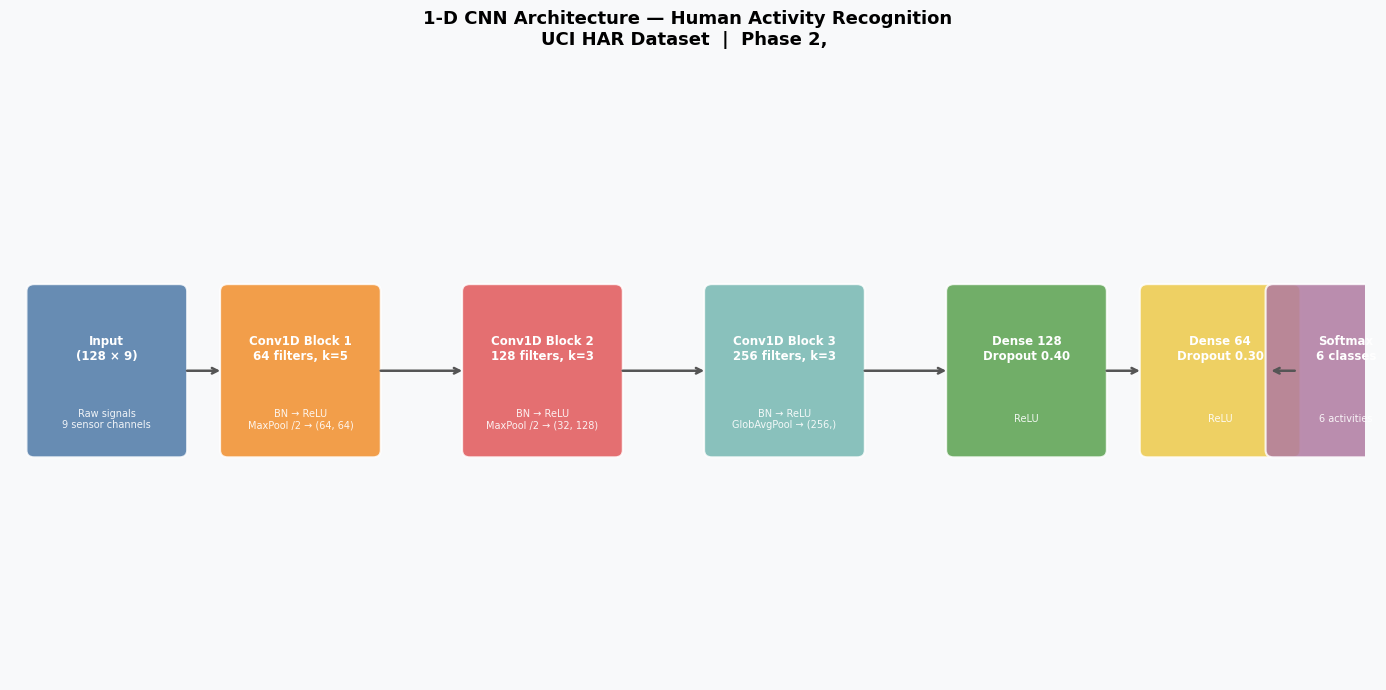

Saved: cnn_architecture_diagram.png


In [25]:

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

layers_info = [

    (1.0,  'Input\n(128 × 9)',        'Raw signals\n9 sensor channels',         '#4e79a7'),
    (3.0,  'Conv1D Block 1\n64 filters, k=5', 'BN → ReLU\nMaxPool /2 → (64, 64)',  '#f28e2b'),
    (5.5,  'Conv1D Block 2\n128 filters, k=3','BN → ReLU\nMaxPool /2 → (32, 128)', '#e15759'),
    (8.0,  'Conv1D Block 3\n256 filters, k=3','BN → ReLU\nGlobAvgPool → (256,)',   '#76b7b2'),
    (10.5, 'Dense 128\nDropout 0.40',  'ReLU',                                    '#59a14f'),
    (12.5, 'Dense 64\nDropout 0.30',   'ReLU',                                    '#edc948'),
    (13.8, f'Softmax\n{NUM_CLASSES} classes', '6 activities',                      '#b07aa1'),
]

BOX_W, BOX_H = 1.5, 1.8
y_center = 3.5

for i, (xc, label, sublabel, color) in enumerate(layers_info):
    # Draw box
    rect = mpatches.FancyBboxPatch(
        (xc - BOX_W/2, y_center - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.08', linewidth=1.5,
        edgecolor='white', facecolor=color, alpha=0.85, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xc, y_center + 0.25, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)
    ax.text(xc, y_center - 0.55, sublabel, ha='center', va='center',
            fontsize=7, color='white', alpha=0.9, zorder=4)


    if i < len(layers_info) - 1:
        x_next = layers_info[i+1][0]
        ax.annotate('', xy=(x_next - BOX_W/2 - 0.05, y_center),
                    xytext=(xc + BOX_W/2 + 0.05, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=5)

ax.set_title('1-D CNN Architecture — Human Activity Recognition\n'
             'UCI HAR Dataset  |  Phase 2, ',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('cnn_architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_architecture_diagram.png')


In [26]:

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

BATCH_SIZE = 64
EPOCHS     = 60

history = cnn_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=0
)

print(f'\nTraining finished after {len(history.history["loss"])} epochs')



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.

Training finished after 14 epochs


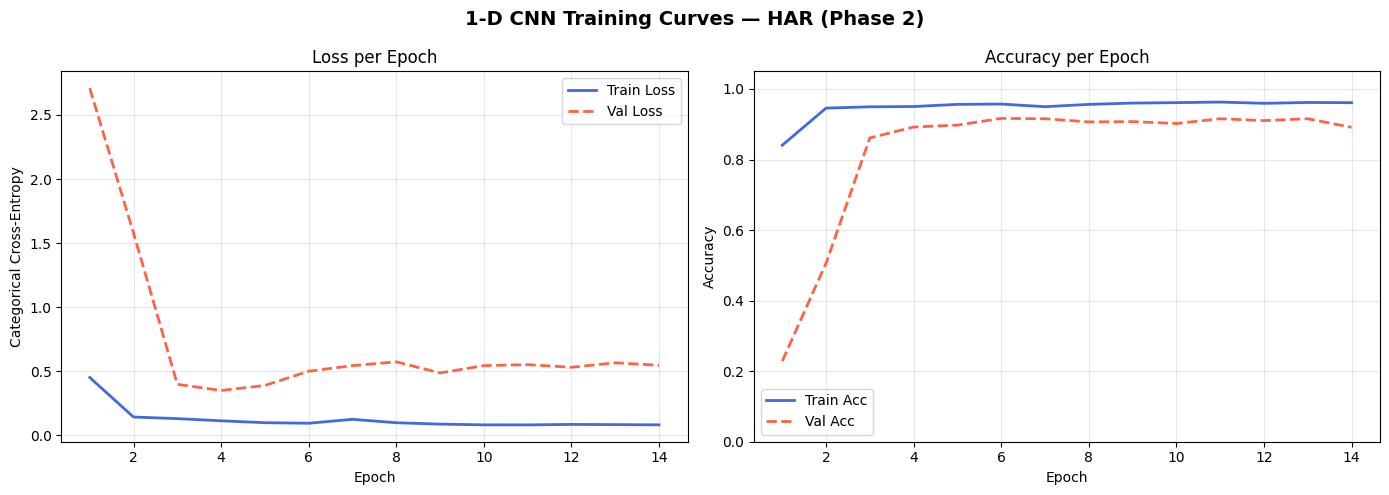

Saved: cnn_training_curves.png


In [27]:

epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1-D CNN Training Curves — HAR (Phase 2)', fontsize=14, fontweight='bold')


axes[0].plot(epochs_ran, history.history['loss'],     'royalblue',  lw=2, label='Train Loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'tomato',     lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_training_curves.png')


In [28]:
test_loss, test_acc = cnn_model.evaluate(X_test_raw, y_test_oh, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

y_pred_prob = cnn_model.predict(X_test_raw, verbose=0)
y_pred_cls  = np.argmax(y_pred_prob, axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test_cnn, y_pred_cls,
                             target_names=le_cnn.classes_))


Test Loss     : 0.2464
Test Accuracy : 0.9192

=== Classification Report ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.85      0.84       491
          STANDING       0.86      0.84      0.85       532
           WALKING       1.00      0.93      0.96       496
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
  WALKING_UPSTAIRS       0.87      0.98      0.92       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



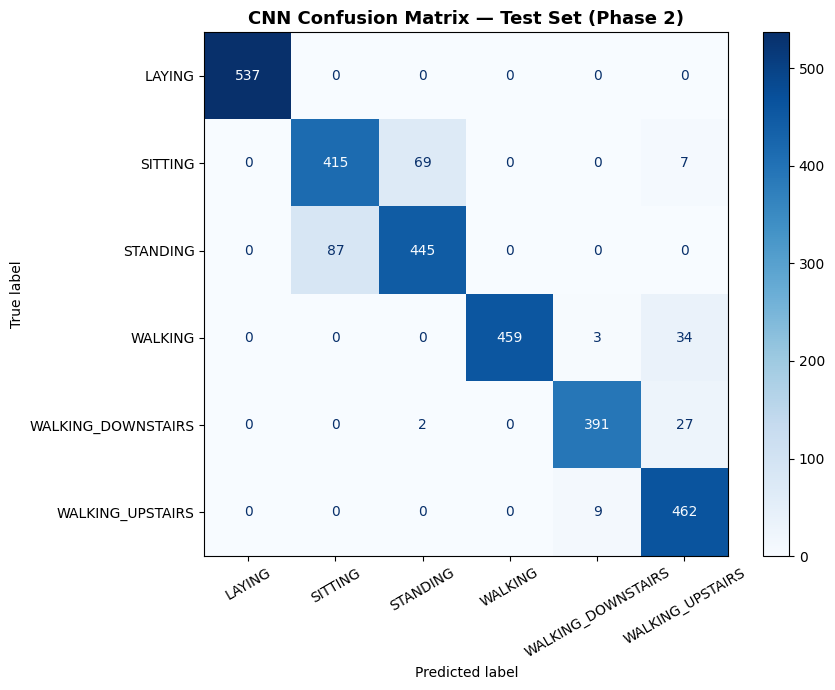

Saved: cnn_confusion_matrix.png


In [29]:
cm   = confusion_matrix(y_test_cnn, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_cnn.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('CNN Confusion Matrix — Test Set (Phase 2)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_confusion_matrix.png')


---
#  — Per-Class F1 Score

In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import seaborn as sns

class_names = le_cnn.classes_

f1_per_class  = f1_score(y_test_cnn, y_pred_cls, average=None)
f1_macro      = f1_score(y_test_cnn, y_pred_cls, average='macro')
f1_weighted   = f1_score(y_test_cnn, y_pred_cls, average='weighted')

f1_df = pd.DataFrame({'Activity': class_names, 'F1 Score': np.round(f1_per_class, 4)})
f1_df = pd.concat([
    f1_df,
    pd.DataFrame([{'Activity': 'Macro Avg',    'F1 Score': round(f1_macro,    4)}]),
    pd.DataFrame([{'Activity': 'Weighted Avg', 'F1 Score': round(f1_weighted, 4)}])
], ignore_index=True)

print('=== Per-Class F1 Score — CNN Model ===')
print(f1_df.to_string(index=False))

=== Per-Class F1 Score — CNN Model ===
          Activity  F1 Score
            LAYING    1.0000
           SITTING    0.8359
          STANDING    0.8492
           WALKING    0.9613
WALKING_DOWNSTAIRS    0.9502
  WALKING_UPSTAIRS    0.9231
         Macro Avg    0.9199
      Weighted Avg    0.9195


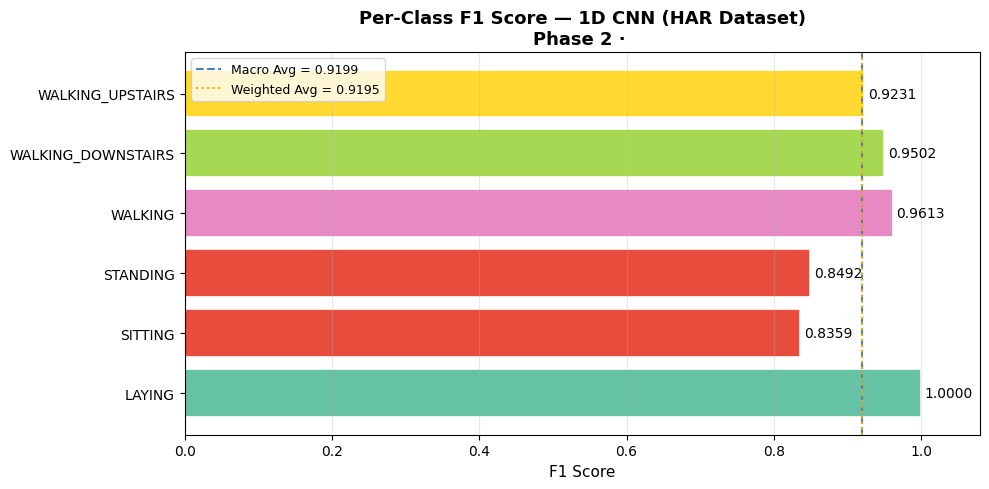

Saved: per_class_f1_cnn.png


In [31]:
plot_df = f1_df[~f1_df['Activity'].isin(['Macro Avg','Weighted Avg'])].copy()
palette = sns.color_palette('Set2', len(plot_df))
colors  = [palette[i] if f > 0.85 else '#e74c3c' for i, f in enumerate(plot_df['F1 Score'])]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_df['Activity'], plot_df['F1 Score'], color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, plot_df['F1 Score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.axvline(x=f1_macro,    color='steelblue', linestyle='--', lw=1.5, label=f'Macro Avg = {f1_macro:.4f}')
ax.axvline(x=f1_weighted, color='orange',    linestyle=':',  lw=1.5, label=f'Weighted Avg = {f1_weighted:.4f}')
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score — 1D CNN (HAR Dataset)\nPhase 2 · ', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_f1_cnn.png')

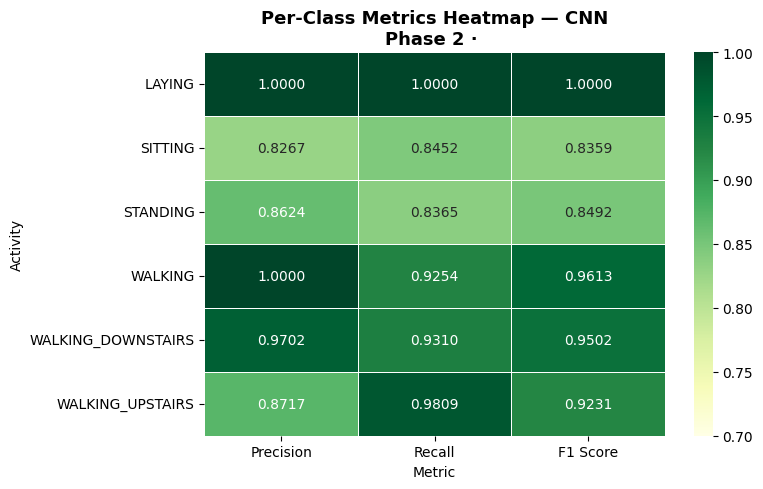

Saved: per_class_metrics_heatmap.png


In [32]:
precision_per = precision_score(y_test_cnn, y_pred_cls, average=None)
recall_per    = recall_score(y_test_cnn,    y_pred_cls, average=None)

metrics_df = pd.DataFrame({
    'Precision' : np.round(precision_per,  4),
    'Recall'    : np.round(recall_per,     4),
    'F1 Score'  : np.round(f1_per_class,   4)
}, index=class_names)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.7, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('Per-Class Metrics Heatmap — CNN\nPhase 2 · ', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Activity')
plt.tight_layout()
plt.savefig('per_class_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_metrics_heatmap.png')

In [33]:
print('=== Full Classification Report (CNN) ===')
print(classification_report(y_test_cnn, y_pred_cls, target_names=class_names, digits=4))

=== Full Classification Report (CNN) ===
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       537
           SITTING     0.8267    0.8452    0.8359       491
          STANDING     0.8624    0.8365    0.8492       532
           WALKING     1.0000    0.9254    0.9613       496
WALKING_DOWNSTAIRS     0.9702    0.9310    0.9502       420
  WALKING_UPSTAIRS     0.8717    0.9809    0.9231       471

          accuracy                         0.9192      2947
         macro avg     0.9218    0.9198    0.9199      2947
      weighted avg     0.9215    0.9192    0.9195      2947



### AE Cell 1 — Build AutoEncoder architecture

In [34]:
def build_autoencoder(input_shape=(128, 9), latent_dim=32):

    inp     = keras.Input(shape=input_shape, name='ae_input')
    x       = layers.Conv1D(64, 5, padding='same', activation='relu', name='enc_conv1')(inp)
    x       = layers.MaxPooling1D(2, name='enc_pool1')(x)
    x       = layers.Conv1D(32, 3, padding='same', activation='relu', name='enc_conv2')(x)
    x       = layers.MaxPooling1D(2, name='enc_pool2')(x)
    x       = layers.Flatten(name='enc_flatten')(x)
    encoded = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    x       = layers.Dense(32 * 32, activation='relu', name='dec_dense')(encoded)
    x       = layers.Reshape((32, 32), name='dec_reshape')(x)
    x       = layers.Conv1DTranspose(32, 3, padding='same', activation='relu', name='dec_deconv1')(x)
    x       = layers.UpSampling1D(2, name='dec_upsample1')(x)
    x       = layers.Conv1DTranspose(64, 5, padding='same', activation='relu', name='dec_deconv2')(x)
    x       = layers.UpSampling1D(2, name='dec_upsample2')(x)
    decoded = layers.Conv1DTranspose(9, 3, padding='same', activation='linear', name='ae_output')(x)

    ae = Model(inp, decoded, name='HAR_AutoEncoder')
    ae.compile(optimizer='adam', loss='mse')
    ae.summary()
    return ae

autoencoder = build_autoencoder(input_shape=(128, 9), latent_dim=32)


Model: "HAR_AutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 64, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 1024)           │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv1DTranspose)   │ (None, 32, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv1DTranspose)   │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_output (Conv1DTranspose)     │ (None, 128, 9)         │         1,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,857 (354.91 KB)

 Trainable params: 90,857 (354.91 KB)

 Non-trainable params: 0 (0.00 B)

### AE Cell 2 — Train AutoEncoder (input = target)

In [35]:
ae_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
]

ae_history = autoencoder.fit(
    X_train_raw, X_train_raw,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=ae_callbacks,
    verbose=0
)

print(f'AE training finished after {len(ae_history.history["loss"])} epochs')
print(f'Final train MSE : {ae_history.history["loss"][-1]:.6f}')
print(f'Final val   MSE : {ae_history.history["val_loss"][-1]:.6f}')


Restoring model weights from the end of the best epoch: 49.
AE training finished after 50 epochs
Final train MSE : 0.020977
Final val   MSE : 0.025394


### AE Cell 3 — Training loss curve

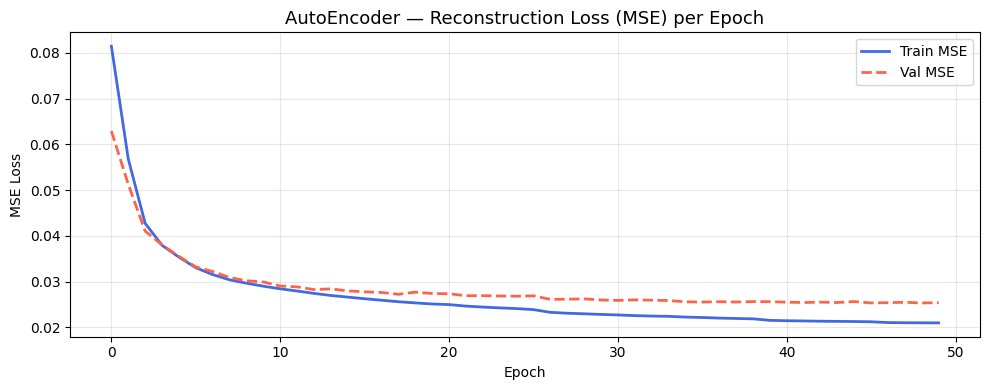

Saved: ae_training_curve.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_history.history['loss'],     label='Train MSE', color='royalblue', lw=2)
ax.plot(ae_history.history['val_loss'], label='Val MSE',   color='tomato',    lw=2, linestyle='--')
ax.set_title('AutoEncoder — Reconstruction Loss (MSE) per Epoch', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ae_training_curve.png')


### AE Cell 4 — Reconstruction error per activity

=== Mean Reconstruction Error per Activity ===
                    count      mean       std       min       25%       50%  \
Activity                                                                      
LAYING              537.0  0.007485  0.022999  0.000131  0.000243  0.000366   
SITTING             491.0  0.001822  0.004568  0.000126  0.000224  0.000327   
STANDING            532.0  0.001653  0.003869  0.000113  0.000269  0.000465   
WALKING             496.0  0.043191  0.024756  0.014009  0.024886  0.036635   
WALKING_DOWNSTAIRS  420.0  0.061060  0.028864  0.015644  0.038597  0.056163   
WALKING_UPSTAIRS    471.0  0.049345  0.031197  0.011115  0.029817  0.037071   

                         75%       max  
Activity                                
LAYING              0.001084  0.154975  
SITTING             0.000843  0.046856  
STANDING            0.001643  0.044973  
WALKING             0.053864  0.146195  
WALKING_DOWNSTAIRS  0.079340  0.155115  
WALKING_UPSTAIRS    0.056108  0.1

/tmp/ipykernel_6703/2746388978.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity', y='Reconstruction Error (MSE)', data=error_df,


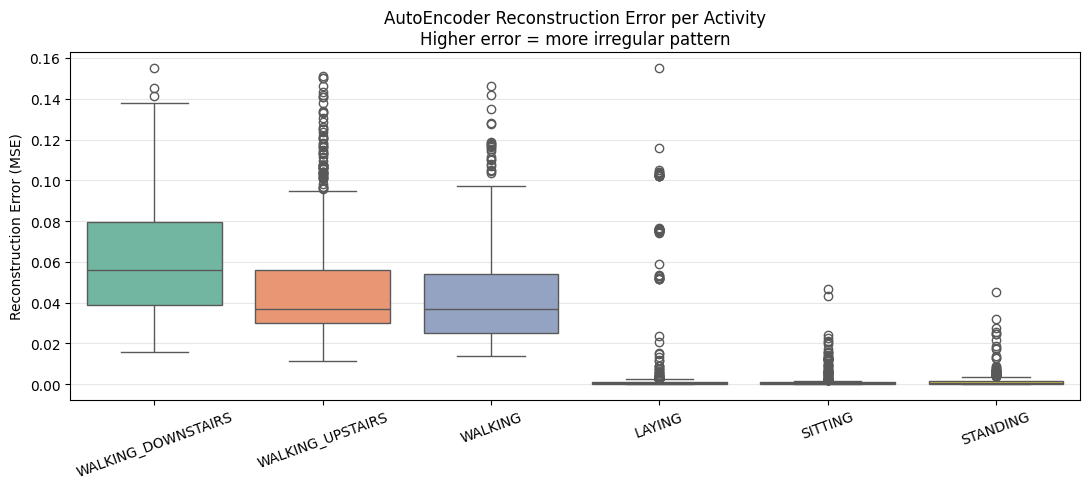

Saved: ae_reconstruction_error_per_activity.png


In [37]:
X_test_reconstructed = autoencoder.predict(X_test_raw, verbose=0)
recon_errors = np.mean((X_test_raw - X_test_reconstructed) ** 2, axis=(1, 2))

error_df = pd.DataFrame({
    'Reconstruction Error (MSE)': recon_errors,
    'Activity': test_data['Activity_Name'].values
})

print('=== Mean Reconstruction Error per Activity ===')
print(error_df.groupby('Activity')['Reconstruction Error (MSE)'].describe().round(6))

fig, ax = plt.subplots(figsize=(11, 5))
order = error_df.groupby('Activity')['Reconstruction Error (MSE)'].mean().sort_values(ascending=False).index
sns.boxplot(x='Activity', y='Reconstruction Error (MSE)', data=error_df,
            order=order, palette='Set2', ax=ax)
ax.set_title('AutoEncoder Reconstruction Error per Activity\nHigher error = more irregular pattern', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ae_reconstruction_error_per_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ae_reconstruction_error_per_activity.png')


### AE Cell 5 — Anomaly detection threshold (95th percentile)

Anomaly Threshold (95th percentile) : 0.074254
Flagged as anomaly : 313 / 2947 (10.6%)

Anomalies per activity:
Activity
WALKING_DOWNSTAIRS    136
WALKING_UPSTAIRS       93
WALKING                52
LAYING                 32
SITTING                 0
STANDING                0
Name: Anomaly, dtype: int64


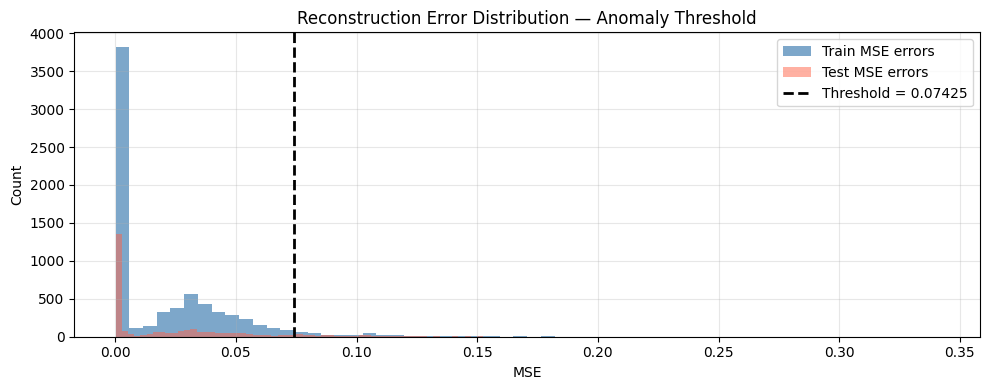

Saved: ae_anomaly_threshold.png


In [38]:
X_train_reconstructed = autoencoder.predict(X_train_raw, verbose=0)
train_errors = np.mean((X_train_raw - X_train_reconstructed) ** 2, axis=(1, 2))

threshold = np.percentile(train_errors, 95)
print(f'Anomaly Threshold (95th percentile) : {threshold:.6f}')

error_df['Anomaly'] = recon_errors > threshold
print(f'Flagged as anomaly : {error_df["Anomaly"].sum()} / {len(error_df)} ({error_df["Anomaly"].mean()*100:.1f}%)')
print('\nAnomalies per activity:')
print(error_df.groupby('Activity')['Anomaly'].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_errors, bins=60, color='steelblue', alpha=0.7, label='Train MSE errors')
ax.hist(recon_errors, bins=60, color='tomato',    alpha=0.5, label='Test MSE errors')
ax.axvline(threshold, color='black', linestyle='--', lw=2, label=f'Threshold = {threshold:.5f}')
ax.set_title('Reconstruction Error Distribution — Anomaly Threshold', fontsize=12)
ax.set_xlabel('MSE'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_anomaly_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ae_anomaly_threshold.png')


### AE Cell 6 — Signal reconstruction visualization

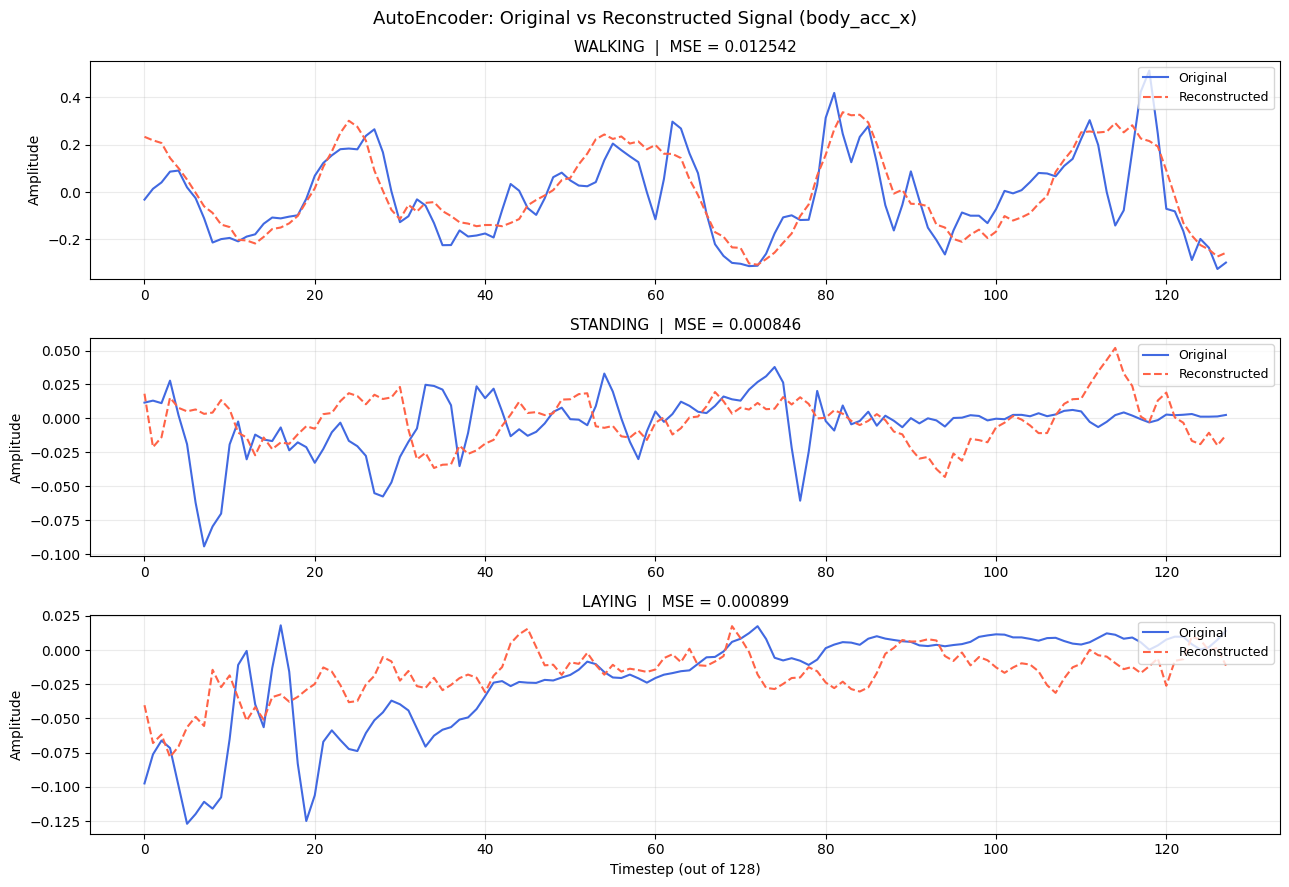

Saved: ae_signal_reconstruction.png


In [39]:
activities_to_show = ['WALKING', 'STANDING', 'LAYING']
signal_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
fig.suptitle('AutoEncoder: Original vs Reconstructed Signal (body_acc_x)', fontsize=13)

for ax, act in zip(axes, activities_to_show):
    pos   = np.where(test_data['Activity_Name'].values == act)[0][0]
    orig  = X_test_raw[pos, :, signal_idx]
    recon = X_test_reconstructed[pos, :, signal_idx]
    mse   = np.mean((orig - recon) ** 2)

    ax.plot(orig,  label='Original',      color='royalblue', lw=1.5)
    ax.plot(recon, label='Reconstructed', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{act}  |  MSE = {mse:.6f}', fontsize=11)
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Timestep (out of 128)')
plt.tight_layout()
plt.savefig('ae_signal_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ae_signal_reconstruction.png')


---
#  — Transfer Learning

In [40]:
import time
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score
print('Imports OK')

Imports OK


In [41]:
le_tl      = LabelEncoder()
y_train_tl = le_tl.fit_transform(train_data['Activity_Name'].values)
y_test_tl  = le_tl.transform(test_data['Activity_Name'].values)
NUM_CLASSES_TL = len(le_tl.classes_)

y_train_oh_tl = to_categorical(y_train_tl, NUM_CLASSES_TL)
y_test_oh_tl  = to_categorical(y_test_tl,  NUM_CLASSES_TL)
print(f'Classes: {list(le_tl.classes_)}')

Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [42]:

def make_head(base_output, num_classes, dropout=0.4):
    x = layers.GlobalAveragePooling1D()(base_output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return layers.Dense(num_classes, activation='softmax')(x)

def train_and_eval(model, name, X_tr, y_tr_oh, X_te, y_te_int,
                   epochs=40, batch=64, patience=8):
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    cb = EarlyStopping(monitor='val_loss', patience=patience,
                       restore_best_weights=True, verbose=0)
    t0   = time.time()
    hist = model.fit(X_tr, y_tr_oh, validation_split=0.15,
                     epochs=epochs, batch_size=batch, callbacks=[cb], verbose=0)
    elapsed = round(time.time() - t0, 1)

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc    = accuracy_score(y_te_int, y_pred)
    f1_w   = f1_score(y_te_int, y_pred, average='weighted')
    f1_m   = f1_score(y_te_int, y_pred, average='macro')
    trainable   = sum(tf.size(v).numpy() for v in model.trainable_weights)
    untrainable = sum(tf.size(v).numpy() for v in model.non_trainable_weights)

    print(f'[{name}] epochs={len(hist.history["loss"])} | acc={acc:.4f} | F1-w={f1_w:.4f} | time={elapsed}s')
    return {'Model': name, 'Trainable Params': trainable, 'Frozen Params': untrainable,
            'Epochs Run': len(hist.history['loss']), 'Test Accuracy': round(acc,4),
            'F1 Weighted': round(f1_w,4), 'F1 Macro': round(f1_m,4), 'Train Time (s)': elapsed}

print('Helpers ready')

Helpers ready


In [43]:
print('=== Scenario A: Train from Scratch ===')

def build_cnn_scratch(input_shape=(128,9), num_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return Model(inp, make_head(x, num_classes), name='Scratch_CNN')

row_A = train_and_eval(build_cnn_scratch(num_classes=NUM_CLASSES_TL), 'A — Scratch CNN',
                       X_train_raw, y_train_oh_tl, X_test_raw, y_test_tl)

=== Scenario A: Train from Scratch ===
[A — Scratch CNN] epochs=12 | acc=0.8616 | F1-w=0.8629 | time=112.8s


In [44]:
print('=== Scenario B: Fine-tune All Layers ===')

base_b = keras.Model(inputs=cnn_model.input,
                     outputs=cnn_model.get_layer('conv3').output,
                     name='base_full_finetune')
for layer in base_b.layers: layer.trainable = True

inp_b  = keras.Input(shape=(128, 9))
feat_b = base_b(inp_b, training=True)
m_b    = Model(inp_b, make_head(feat_b, NUM_CLASSES_TL), name='FineTune_All')

row_B = train_and_eval(m_b, 'B — Fine-tune All Layers',
                       X_train_raw, y_train_oh_tl, X_test_raw, y_test_tl, epochs=30, patience=6)

=== Scenario B: Fine-tune All Layers ===
[B — Fine-tune All Layers] epochs=9 | acc=0.8867 | F1-w=0.8873 | time=69.2s


In [45]:
print('=== Scenario C: Freeze Early Layers ===')

base_c = keras.Model(inputs=cnn_model.input,
                     outputs=cnn_model.get_layer('conv3').output,
                     name='base_partial_freeze')
freeze_names = {'conv1','bn1','relu1','pool1','conv2','bn2','relu2','pool2'}
for layer in base_c.layers:
    layer.trainable = (layer.name not in freeze_names)

inp_c  = keras.Input(shape=(128, 9))
feat_c = base_c(inp_c, training=True)
m_c    = Model(inp_c, make_head(feat_c, NUM_CLASSES_TL), name='FineTune_Partial')

row_C = train_and_eval(m_c, 'C — Freeze Early (conv1+conv2)',
                       X_train_raw, y_train_oh_tl, X_test_raw, y_test_tl, epochs=30, patience=6)

=== Scenario C: Freeze Early Layers ===
[C — Freeze Early (conv1+conv2)] epochs=7 | acc=0.9247 | F1-w=0.9245 | time=28.3s


In [46]:
print('=== Scenario D: Feature Extractor (All Frozen) ===')

base_d = keras.Model(inputs=cnn_model.input,
                     outputs=cnn_model.get_layer('conv3').output,
                     name='base_feature_extractor')
for layer in base_d.layers: layer.trainable = False

inp_d  = keras.Input(shape=(128, 9))
feat_d = base_d(inp_d, training=False)
m_d    = Model(inp_d, make_head(feat_d, NUM_CLASSES_TL), name='FeatureExtractor')

row_D = train_and_eval(m_d, 'D — Feature Extractor (all frozen)',
                       X_train_raw, y_train_oh_tl, X_test_raw, y_test_tl)

=== Scenario D: Feature Extractor (All Frozen) ===
[D — Feature Extractor (all frozen)] epochs=9 | acc=0.9206 | F1-w=0.9204 | time=21.8s


In [47]:
tl_results = pd.DataFrame([row_A, row_B, row_C, row_D])

print('\n' + '='*65)
print('       TRANSFER LEARNING COMPARISON TABLE — Phase 2')
print('='*65)
print(tl_results.to_string(index=False))
print('='*65)
print(f"\nBest Accuracy : {tl_results.loc[tl_results['Test Accuracy'].idxmax(), 'Model']}")
print(f"Best F1 (w)   : {tl_results.loc[tl_results['F1 Weighted'].idxmax(),  'Model']}")


       TRANSFER LEARNING COMPARISON TABLE — Phase 2
                             Model  Trainable Params  Frozen Params  Epochs Run  Test Accuracy  F1 Weighted  F1 Macro  Train Time (s)
                   A — Scratch CNN            168646            896          12         0.8616       0.8629    0.8645           112.8
          B — Fine-tune All Layers            168134            384           9         0.8867       0.8873    0.8866            69.2
    C — Freeze Early (conv1+conv2)            140102          28416           7         0.9247       0.9245    0.9253            28.3
D — Feature Extractor (all frozen)             41542         126976           9         0.9206       0.9204    0.9214            21.8

Best Accuracy : C — Freeze Early (conv1+conv2)
Best F1 (w)   : C — Freeze Early (conv1+conv2)


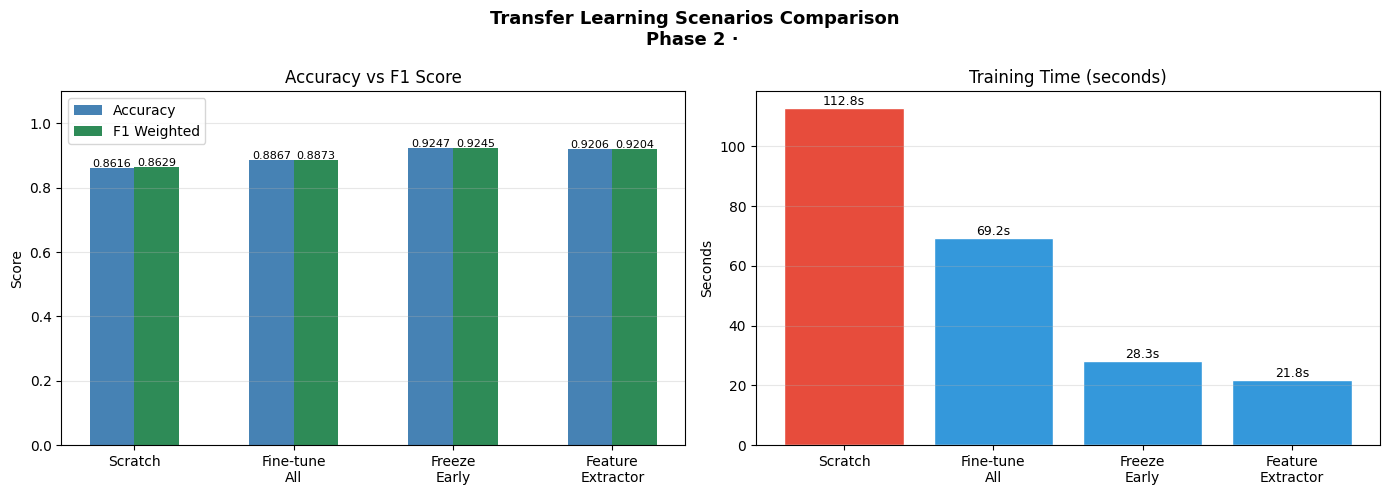

Saved: transfer_learning_comparison.png


In [48]:
models_short = ['Scratch', 'Fine-tune\nAll', 'Freeze\nEarly', 'Feature\nExtractor']
x     = np.arange(len(tl_results))
width = 0.28

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning Scenarios Comparison\nPhase 2 · ', fontsize=13, fontweight='bold')


bars1 = axes[0].bar(x - width/2, tl_results['Test Accuracy'], width, label='Accuracy',    color='steelblue')
bars2 = axes[0].bar(x + width/2, tl_results['F1 Weighted'],   width, label='F1 Weighted', color='seagreen')
for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                     f'{bar.get_height():.4f}', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_short)
axes[0].set_ylim(0, 1.1); axes[0].set_title('Accuracy vs F1 Score')
axes[0].set_ylabel('Score'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)


colors_t = ['#e74c3c' if t == tl_results['Train Time (s)'].max() else '#3498db'
            for t in tl_results['Train Time (s)']]
bars3 = axes[1].bar(x, tl_results['Train Time (s)'], color=colors_t, edgecolor='white')
for bar, val in zip(bars3, tl_results['Train Time (s)']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}s', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_short)
axes[1].set_title('Training Time (seconds)'); axes[1].set_ylabel('Seconds')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_learning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: transfer_learning_comparison.png')

### Opt Cell 1 — Train with Adam optimizer

In [49]:
import time

def build_cnn_for_opt(input_shape=(128, 9), num_classes=6):
    inp = keras.Input(shape=input_shape)
    x   = layers.Conv1D(64,  5, padding='same')(inp)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.MaxPooling1D(2)(x)
    x   = layers.Conv1D(128, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.MaxPooling1D(2)(x)
    x   = layers.Conv1D(256, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.4)(x)
    x   = layers.Dense(64,  activation='relu')(x); x = layers.Dropout(0.3)(x)
    return Model(inp, layers.Dense(num_classes, activation='softmax')(x))

OPT_EPOCHS = 40
OPT_BATCH  = 64
opt_cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)]

print('Training with Adam...')
model_adam = build_cnn_for_opt(num_classes=NUM_CLASSES)
model_adam.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
t0_adam   = time.time()
hist_adam = model_adam.fit(X_train_raw, y_train_oh, validation_split=0.15,
                           epochs=OPT_EPOCHS, batch_size=OPT_BATCH, callbacks=opt_cb, verbose=0)
time_adam  = round(time.time() - t0_adam, 1)
adam_epochs = len(hist_adam.history['loss'])
print(f'Adam done — {adam_epochs} epochs in {time_adam}s')


Training with Adam...
Adam done — 14 epochs in 173.2s


### Opt Cell 2 — Train with SGD + Momentum

In [50]:
print('Training with SGD + Momentum...')
model_sgd = build_cnn_for_opt(num_classes=NUM_CLASSES)
model_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0_sgd   = time.time()
hist_sgd = model_sgd.fit(X_train_raw, y_train_oh, validation_split=0.15,
                         epochs=OPT_EPOCHS, batch_size=OPT_BATCH, callbacks=opt_cb, verbose=0)
time_sgd  = round(time.time() - t0_sgd, 1)
sgd_epochs = len(hist_sgd.history['loss'])
print(f'SGD done — {sgd_epochs} epochs in {time_sgd}s')


Training with SGD + Momentum...
SGD done — 20 epochs in 242.1s


### Opt Cell 3 — Training curves comparison (Loss + Accuracy)

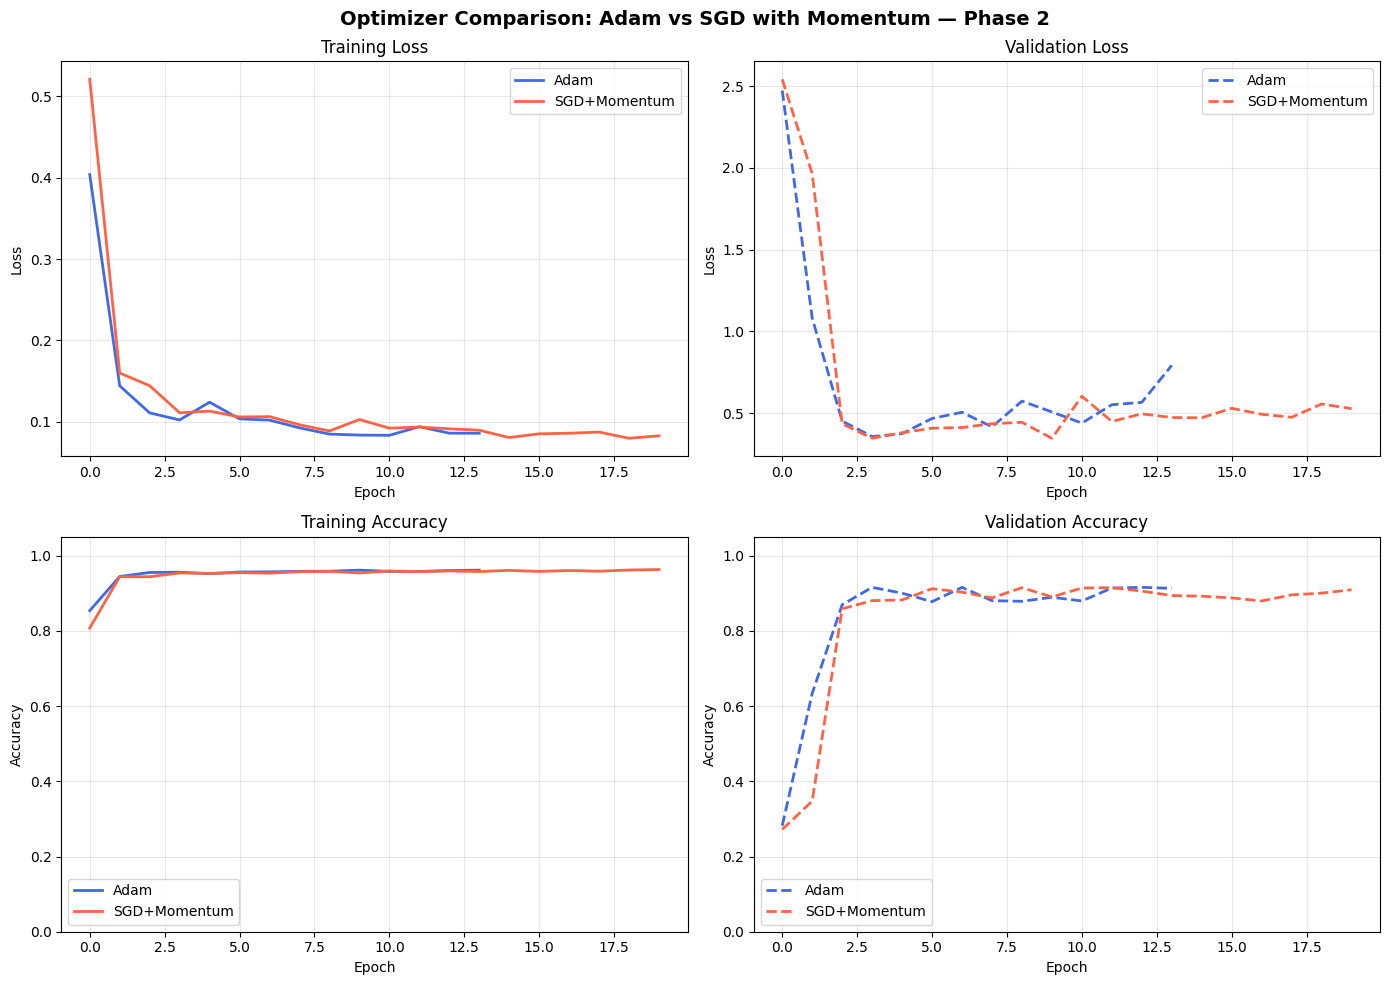

Saved: optimizer_comparison_curves.png


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimizer Comparison: Adam vs SGD with Momentum — Phase 2', fontsize=14, fontweight='bold')

axes[0,0].plot(hist_adam.history['loss'], color='royalblue', lw=2, label='Adam')
axes[0,0].plot(hist_sgd.history['loss'],  color='tomato',    lw=2, label='SGD+Momentum')
axes[0,0].set_title('Training Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(hist_adam.history['val_loss'], color='royalblue', lw=2, label='Adam',        linestyle='--')
axes[0,1].plot(hist_sgd.history['val_loss'],  color='tomato',    lw=2, label='SGD+Momentum', linestyle='--')
axes[0,1].set_title('Validation Loss'); axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(hist_adam.history['accuracy'], color='royalblue', lw=2, label='Adam')
axes[1,0].plot(hist_sgd.history['accuracy'],  color='tomato',    lw=2, label='SGD+Momentum')
axes[1,0].set_title('Training Accuracy'); axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_ylim(0, 1.05); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(hist_adam.history['val_accuracy'], color='royalblue', lw=2, label='Adam',        linestyle='--')
axes[1,1].plot(hist_sgd.history['val_accuracy'],  color='tomato',    lw=2, label='SGD+Momentum', linestyle='--')
axes[1,1].set_title('Validation Accuracy'); axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_ylim(0, 1.05); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimizer_comparison_curves.png')


### Opt Cell 4 — Final comparison table + bar chart


        OPTIMIZER COMPARISON TABLE — Phase 2
                      Optimizer  Test Accuracy  F1 Weighted  F1 Macro  Epochs Run  Train Time (s)       Convergence
                Adam (lr=0.001)         0.9155       0.9156    0.9170          14           173.2              Fast
SGD + Momentum (lr=0.01, m=0.9)         0.9413       0.9405    0.9411          20           242.1 Slower but stable


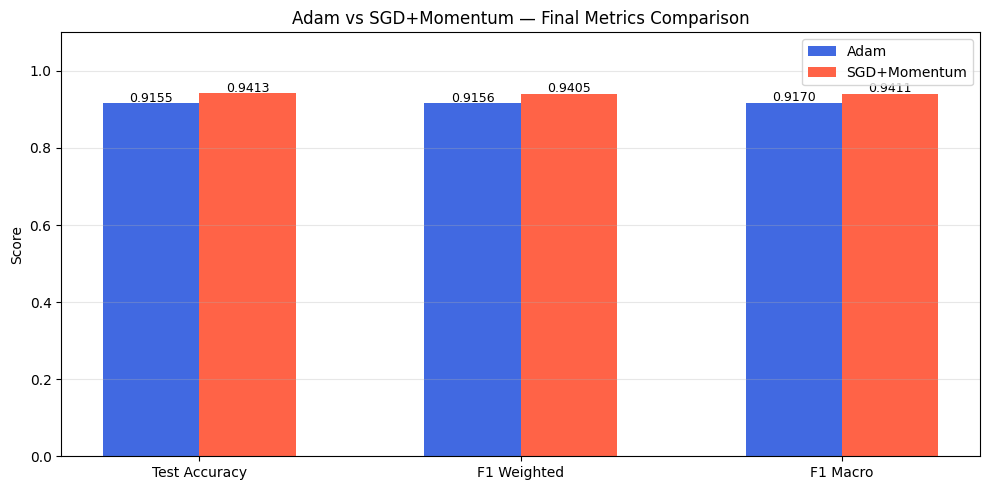

Saved: optimizer_comparison_bar.png


In [52]:
from sklearn.metrics import f1_score as f1_s

y_pred_adam = np.argmax(model_adam.predict(X_test_raw, verbose=0), axis=1)
y_pred_sgd  = np.argmax(model_sgd.predict(X_test_raw,  verbose=0), axis=1)

opt_results = pd.DataFrame([
    {'Optimizer': 'Adam (lr=0.001)',
     'Test Accuracy': round(np.mean(y_pred_adam == y_test_cnn), 4),
     'F1 Weighted'  : round(f1_s(y_test_cnn, y_pred_adam, average='weighted'), 4),
     'F1 Macro'     : round(f1_s(y_test_cnn, y_pred_adam, average='macro'), 4),
     'Epochs Run'   : adam_epochs, 'Train Time (s)': time_adam, 'Convergence': 'Fast'},
    {'Optimizer': 'SGD + Momentum (lr=0.01, m=0.9)',
     'Test Accuracy': round(np.mean(y_pred_sgd == y_test_cnn), 4),
     'F1 Weighted'  : round(f1_s(y_test_cnn, y_pred_sgd, average='weighted'), 4),
     'F1 Macro'     : round(f1_s(y_test_cnn, y_pred_sgd, average='macro'), 4),
     'Epochs Run'   : sgd_epochs, 'Train Time (s)': time_sgd, 'Convergence': 'Slower but stable'}
])

print('\n' + '='*70)
print('        OPTIMIZER COMPARISON TABLE — Phase 2')
print('='*70)
print(opt_results.to_string(index=False))
print('='*70)

metrics = ['Test Accuracy', 'F1 Weighted', 'F1 Macro']
x, w    = np.arange(len(metrics)), 0.3
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, opt_results.loc[0, metrics], w, label='Adam',         color='royalblue')
b2 = ax.bar(x + w/2, opt_results.loc[1, metrics], w, label='SGD+Momentum', color='tomato')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{bar.get_height():.4f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Adam vs SGD+Momentum — Final Metrics Comparison', fontsize=12)
ax.set_ylabel('Score'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('optimizer_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimizer_comparison_bar.png')
